In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("Data/Mall_Customers.csv")

# display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# check dataset info (rows, columns, data types)
df.info()

# check for missing values
df.isnull().sum()

# check basic statistics
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [3]:
# select features for clustering (Annual Income and Spending Score)
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# display selected features
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


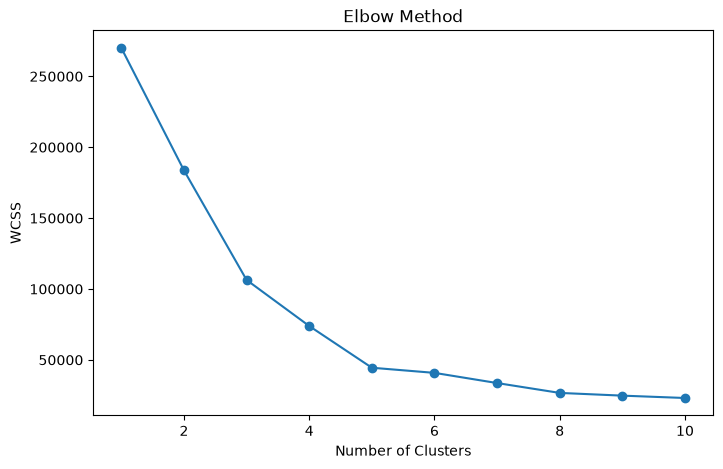

In [4]:
# import KMeans
from sklearn.cluster import KMeans

# find WCSS (within cluster sum of squares) for different k values
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# plot elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [5]:
# apply KMeans clustering with 5 clusters
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42)

# fit and predict cluster labels
y_kmeans = kmeans.fit_predict(X)

# add cluster labels to original dataframe
df["Cluster"] = y_kmeans

# display updated dataframe
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


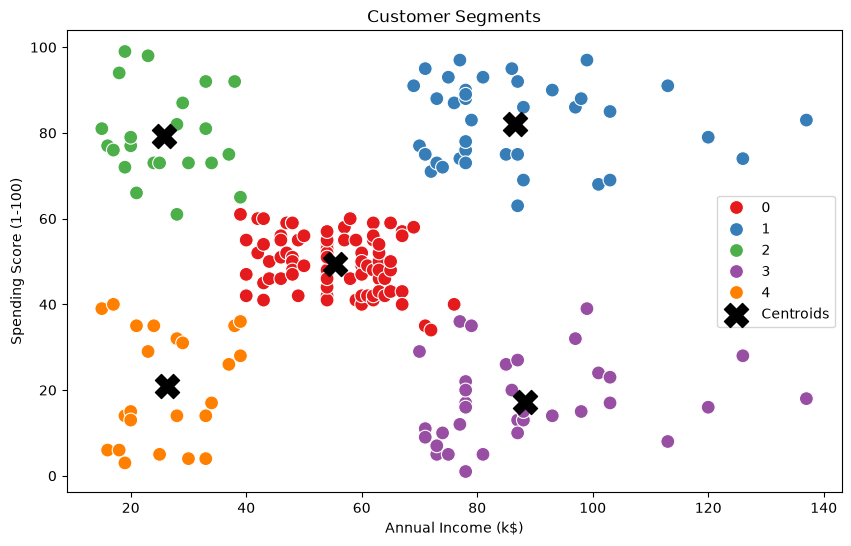

In [6]:
# plot clusters with different colors
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"], 
                 hue=df["Cluster"], palette="Set1", s=100)

# plot cluster centers
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            s=300, c="black", marker="X", label="Centroids")

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [7]:
# calculate average values for each cluster
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

# display cluster summary
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


## Conclusion

Using K-Means clustering, mall customers were segmented into **5 groups** based on their Annual Income and Spending Score:

1. **Cluster 0 – Average Customers**: Medium income, medium spending.
2. **Cluster 1 – Premium/Target Customers**: High income, high spending. Most valuable segment for marketing.
3. **Cluster 2 – Careless Spenders**: Young, low income, but high spending.
4. **Cluster 3 – Cautious Customers**: High income, low spending. Potential to increase engagement with offers.
5. **Cluster 4 – Budget-Conscious Customers**: Low income, low spending.

These insights can help the mall design targeted marketing strategies for each customer segment.